<a href="https://colab.research.google.com/github/alansiny/INTERSHIP-AI-ML/blob/main/brain_tumor_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 3c7b18a8-c266-455c-b552-dd660d9fac50.jpg to 3c7b18a8-c266-455c-b552-dd660d9fac50.jpg


In [ ]:
import zipfile

with zipfile.ZipFile('/content/archive (21).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/brain_tumor_data')

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    '/content/brain_tumor_data',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    '/content/brain_tumor_data',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 406 images belonging to 3 classes.
Found 100 images belonging to 3 classes.


In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)



In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.2488 - loss: 0.8289 - val_accuracy: 0.1900 - val_loss: 0.3594
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.1946 - loss: 0.5353 - val_accuracy: 0.1900 - val_loss: 0.2926
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.1921 - loss: 0.6139 - val_accuracy: 0.1900 - val_loss: 0.3260
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.1946 - loss: 0.5516 - val_accuracy: 0.1900 - val_loss: 0.4512
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.1946 - loss: 0.5186 - val_accuracy: 0.1900 - val_loss: 0.3002
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.1946 - loss: 0.5517 - val_accuracy: 0.1900 - val_loss: 0.4063
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.1946 - loss: 0.5239 - val_accuracy: 0.1900 - val_loss: 0.3654
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.1946 - loss: 0.6055 - val_accuracy: 0.1900 - val_loss:

In [ ]:
model.save('brain_tumor_model.h5')

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    '/content/3c7b18a8-c266-455c-b552-dd660d9fac50.jpg',
    target_size=(224,224)
)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Tumor Detected")
else:
    print("No Tumor")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
Tumor Detected


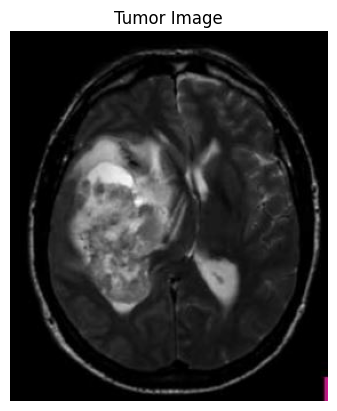

In [ ]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

dataset_path = "/content/brain_tumor_data/brain_tumor_dataset"

yes_path = os.path.join(dataset_path, "yes")
no_path = os.path.join(dataset_path, "no")

# Display one tumor image
tumor_img = os.path.join(yes_path, os.listdir(yes_path)[0])

img = image.load_img(tumor_img)
plt.imshow(img)
plt.title("Tumor Image")
plt.axis("off")
plt.show()